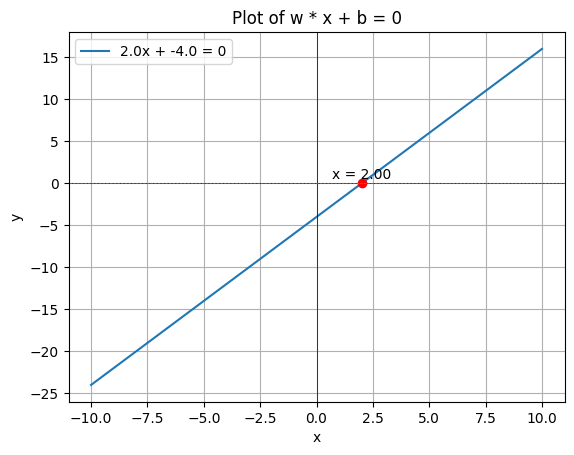

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Define w and b
w = 2.0   # slope
b = -4.0  # bias / intercept

# Create a range of x values
x = np.linspace(-10, 10, 100)

# Compute y values for the line: w * x + b
y = w * x + b

# Plot the line
plt.plot(x, y, label=f'{w}x + {b} = 0')
plt.axhline(0, color='black', linewidth=0.5)  # x-axis
plt.axvline(0, color='black', linewidth=0.5)  # y-axis

# Highlight the point where y = 0 (i.e., the solution to w*x + b = 0)
x_zero = -b / w
plt.plot(x_zero, 0, 'ro')  # red dot at the root
plt.text(x_zero, 0.5, f'x = {x_zero:.2f}', ha='center')

# Labels and grid
plt.title('Plot of w * x + b = 0')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend()
plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)

plt.show()


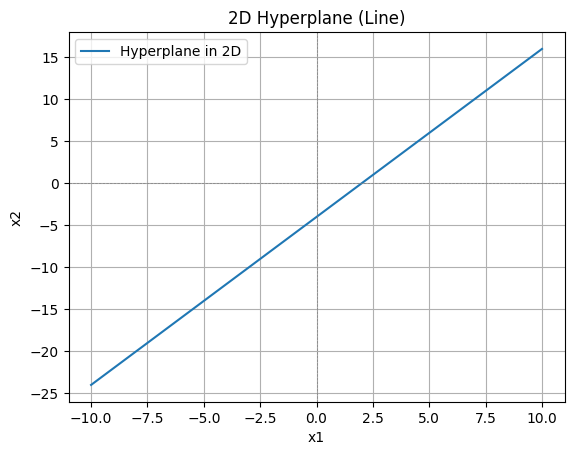

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Define weights and bias
w1 = 2
w2 = -1
b = -4

# x1 values
x1 = np.linspace(-10, 10, 100)

# Solve for x2: w1*x1 + w2*x2 + b = 0  =>  x2 = -(w1*x1 + b)/w2
x2 = -(w1 * x1 + b) / w2

# Plot
plt.plot(x1, x2, label='Hyperplane in 2D')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('2D Hyperplane (Line)')
plt.grid(True)
plt.legend()
plt.show()


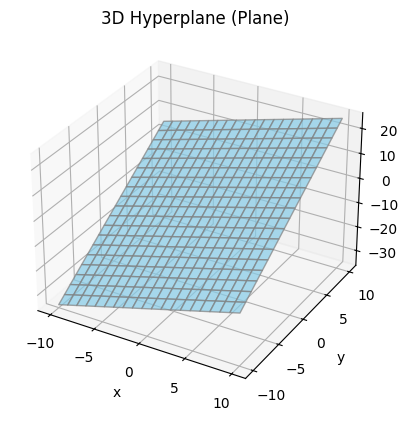

In [3]:
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import matplotlib.pyplot as plt
import numpy as np

# Define weights and bias
w1 = 1
w2 = 2
w3 = -1
b = -5

# Create a meshgrid for x and y
x_vals = np.linspace(-10, 10, 20)
y_vals = np.linspace(-10, 10, 20)
x, y = np.meshgrid(x_vals, y_vals)

# Solve for z: w1*x + w2*y + w3*z + b = 0 => z = -(w1*x + w2*y + b)/w3
z = -(w1 * x + w2 * y + b) / w3

# Plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x, y, z, alpha=0.7, color='skyblue', edgecolor='gray')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('3D Hyperplane (Plane)')
plt.show()


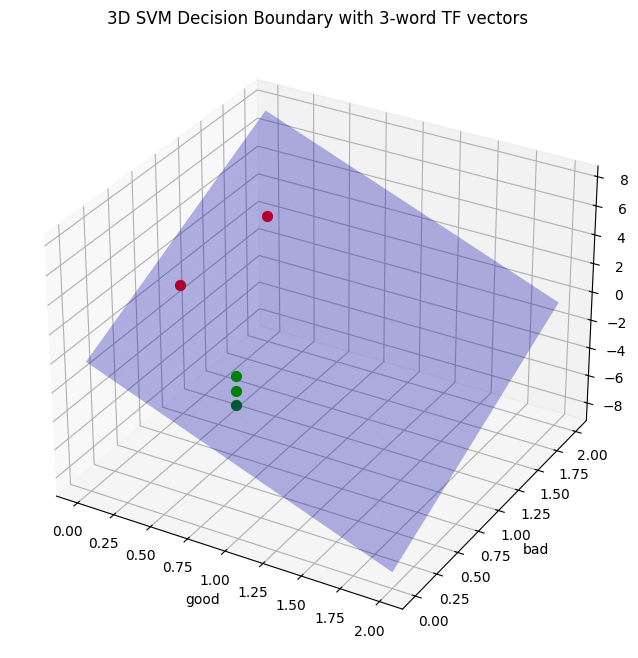

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.svm import LinearSVC

# Sample data: each row is [good, bad, amazing]
X = np.array([
    [1, 0, 1],  # good amazing
    [0, 2, 0],  # bad bad
    [1, 0, 0],  # good
    [0, 1, 0],  # bad
    [1, 0, 2],  # good amazing amazing
])
y = np.array([1, -1, 1, -1, 1])  # 1 = positive, -1 = negative

# Train Linear SVM
clf = LinearSVC(C=1.0)
clf.fit(X, y)

# Extract hyperplane parameters
w = clf.coef_[0]
b = clf.intercept_[0]

# Create 3D grid to plot hyperplane
xx, yy = np.meshgrid(np.linspace(0, 2, 10), np.linspace(0, 2, 10))
# Solve for z in the plane equation: w1*x + w2*y + w3*z + b = 0
# => z = -(w1*x + w2*y + b)/w3
if w[2] != 0:
    zz = -(w[0]*xx + w[1]*yy + b) / w[2]
else:
    zz = np.zeros_like(xx)

# Plotting
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot points
for i in range(len(X)):
    color = 'green' if y[i] == 1 else 'red'
    ax.scatter(X[i,0], X[i,1], X[i,2], color=color, s=50)

# Plot hyperplane
ax.plot_surface(xx, yy, zz, alpha=0.3, color='blue')

ax.set_xlabel('good')
ax.set_ylabel('bad')
ax.set_zlabel('amazing')
ax.set_title('3D SVM Decision Boundary with 3-word TF vectors')
plt.show()


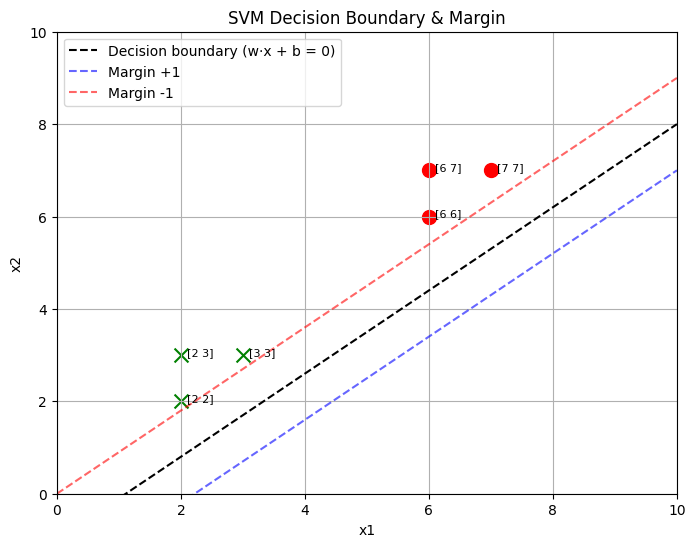

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# === Define your data ===
points = np.array([
    [2, 2],  # Positive
    [3, 3],  # Positive
    [2, 3],  # Positive
    [6, 6],  # Negative
    [7, 7],  # Negative
    [6, 7]   # Negative
])
labels = np.array([1, 1, 1, -1, -1, -1])  # +1 = positive, -1 = negative

# === Set your weight vector and bias ===
# Modify these to see how the decision boundary changes
w = np.array([0.9, -1])  # Try changing to [1, 1], [2, -1], etc.
b = -1                # Try changing to 0, -2, etc.

# === Calculate scores ===
scores = np.dot(points, w) + b
predicted_labels = np.sign(scores)

# === Plot ===
fig, ax = plt.subplots(figsize=(8, 6))

# Plot points
for i, point in enumerate(points):
    color = 'green' if labels[i] == 1 else 'red'
    marker = 'o' if labels[i] == predicted_labels[i] else 'x'
    ax.scatter(point[0], point[1], color=color, s=100, marker=marker)
    ax.text(point[0] + 0.1, point[1], f"{point}", fontsize=8)

# Plot decision boundary and margins
x_vals = np.linspace(0, 10, 100)
if w[1] != 0:
    decision_boundary = -(w[0] * x_vals + b) / w[1]
    margin_pos = -(w[0] * x_vals + b - 1) / w[1]
    margin_neg = -(w[0] * x_vals + b + 1) / w[1]

    ax.plot(x_vals, decision_boundary, 'k--', label='Decision boundary (w·x + b = 0)')
    ax.plot(x_vals, margin_pos, 'b--', alpha=0.6, label='Margin +1')
    ax.plot(x_vals, margin_neg, 'r--', alpha=0.6, label='Margin -1')

# Final plot settings
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_title("SVM Decision Boundary & Margin")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.grid(True)
ax.legend()
plt.show()


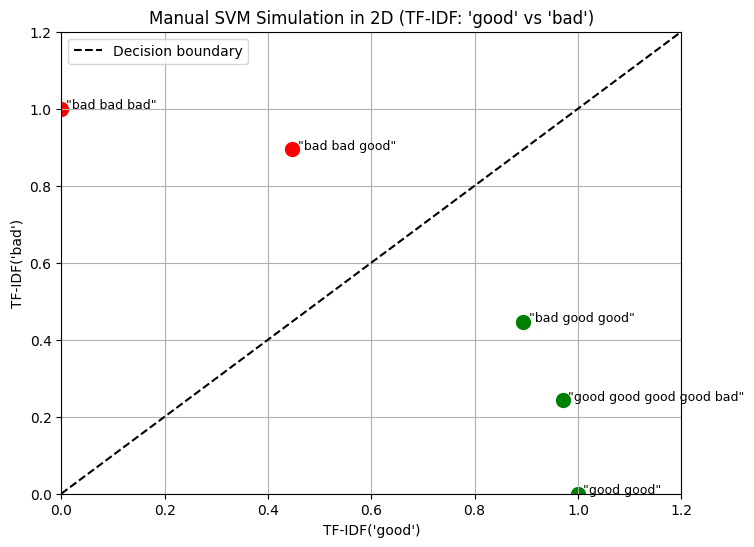

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

# === Sentences and their labels ===
sentences = [
    "good good good good bad",   # Positive
    "bad bad good",              # Negative
    "bad bad bad",               # Negative
    "good good",                 # Positive
    "bad good good",             # Positive
]
labels = [1, -1, -1, 1, 1]  # +1 for positive, -1 for negative

# === TF-IDF vectorization with limited vocabulary ===
vectorizer = TfidfVectorizer(vocabulary=["good", "bad"])
X = vectorizer.fit_transform(sentences).toarray()

# === Manually set weights and bias ===
# Modify these to experiment


w = np.array([1, -1])  # weight for "good", weight for "bad"
b = 0                  # bias

# === Predict using manual weights ===
scores = X @ w + b
predicted_labels = np.sign(scores)

# === Plotting ===
fig, ax = plt.subplots(figsize=(8, 6))
for i in range(len(X)):
    color = 'green' if labels[i] == 1 else 'red'
    marker = 'o' if predicted_labels[i] == labels[i] else 'x'
    ax.scatter(X[i, 0], X[i, 1], color=color, s=100, marker=marker)
    ax.text(X[i, 0] + 0.01, X[i, 1], f'"{sentences[i]}"', fontsize=9)

# Plot decision boundary: w1 * x + w2 * y + b = 0 → y = -(w1*x + b)/w2
x_vals = np.linspace(0, 1.2, 100)
if w[1] != 0:
    y_vals = -(w[0] * x_vals + b) / w[1]
    ax.plot(x_vals, y_vals, 'k--', label='Decision boundary')

# Final plot setup
ax.set_xlabel("TF-IDF('good')")
ax.set_ylabel("TF-IDF('bad')")
ax.set_title("Manual SVM Simulation in 2D (TF-IDF: 'good' vs 'bad')")
ax.set_xlim(0, 1.2)
ax.set_ylim(0, 1.2)
ax.grid(True)
ax.legend()
plt.show()



TF-IDF Vectors (columns: 'good', 'bad'):

Sentence 1: good good good good bad
TF-IDF vector: [0.9701425  0.24253563]
--------------------------------------------------
Sentence 2: bad bad bad bad good
TF-IDF vector: [0.24253563 0.9701425 ]
--------------------------------------------------
Sentence 3: bad bad bad
TF-IDF vector: [0. 1.]
--------------------------------------------------
Sentence 4: good good
TF-IDF vector: [1. 0.]
--------------------------------------------------
Sentence 5: bad good good
TF-IDF vector: [0.89442719 0.4472136 ]
--------------------------------------------------


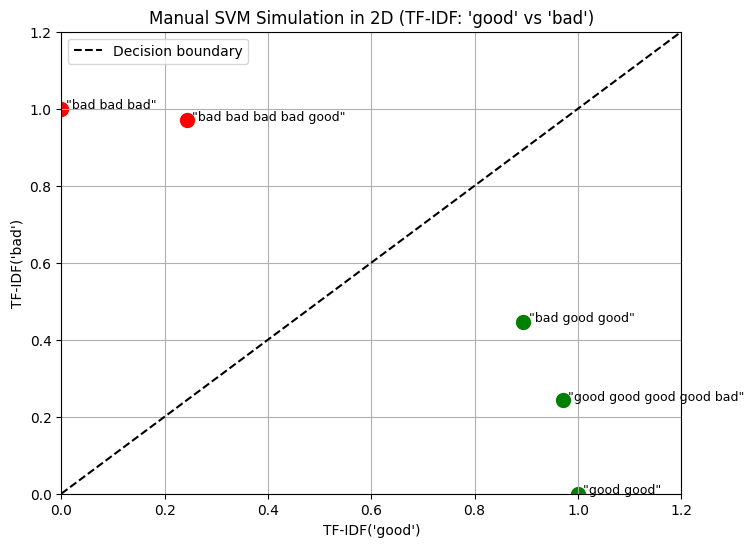

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

# === Sentences and their labels ===
sentences = [
    "good good good good bad",   # Positive
    "bad bad bad bad good",              # Negative
    "bad bad bad",               # Negative
    "good good",                 # Positive
    "bad good good",             # Positive
]
labels = [1, -1, -1, 1, 1]  # +1 for positive, -1 for negative

# === TF-IDF vectorization with limited vocabulary ===
vectorizer = TfidfVectorizer(vocabulary=["good", "bad"])
X = vectorizer.fit_transform(sentences).toarray()

# === Print the TF-IDF vectors ===
print("\nTF-IDF Vectors (columns: 'good', 'bad'):\n")
for i, vector in enumerate(X):
    print(f"Sentence {i+1}: {sentences[i]}")
    print(f"TF-IDF vector: {vector}")
    print("-" * 50)

# === Manually set weights and bias ===
# Modify these to experiment
w = np.array([1, -1])  # weight for "good", weight for "bad"
b = 0                  # bias

# === Predict using manual weights ===
scores = X @ w + b
predicted_labels = np.sign(scores)

# === Plotting ===
fig, ax = plt.subplots(figsize=(8, 6))
for i in range(len(X)):
    color = 'green' if labels[i] == 1 else 'red'
    marker = 'o' if predicted_labels[i] == labels[i] else 'x'
    ax.scatter(X[i, 0], X[i, 1], color=color, s=100, marker=marker)
    ax.text(X[i, 0] + 0.01, X[i, 1], f'"{sentences[i]}"', fontsize=9)

# Plot decision boundary: w1 * x + w2 * y + b = 0 → y = -(w1*x + b)/w2
x_vals = np.linspace(0, 1.2, 100)
if w[1] != 0:
    y_vals = -(w[0] * x_vals + b) / w[1]
    ax.plot(x_vals, y_vals, 'k--', label='Decision boundary')

# Final plot setup
ax.set_xlabel("TF-IDF('good')")
ax.set_ylabel("TF-IDF('bad')")
ax.set_title("Manual SVM Simulation in 2D (TF-IDF: 'good' vs 'bad')")
ax.set_xlim(0, 1.2)
ax.set_ylim(0, 1.2)
ax.grid(True)
ax.legend()
plt.show()



TF-IDF Vectors (columns: 'good', 'bad'):

Sentence 1: good good good good bad
TF-IDF vector: [0.9701425  0.24253563]
--------------------------------------------------
Sentence 2: bad bad bad bad good
TF-IDF vector: [0.24253563 0.9701425 ]
--------------------------------------------------
Sentence 3: bad bad bad
TF-IDF vector: [0. 1.]
--------------------------------------------------
Sentence 4: good good
TF-IDF vector: [1. 0.]
--------------------------------------------------
Sentence 5: bad good good
TF-IDF vector: [0.89442719 0.4472136 ]
--------------------------------------------------

Optimized w: [ 1.86676919 -1.49746725]
Optimized b: -1.4111705269496056e-06


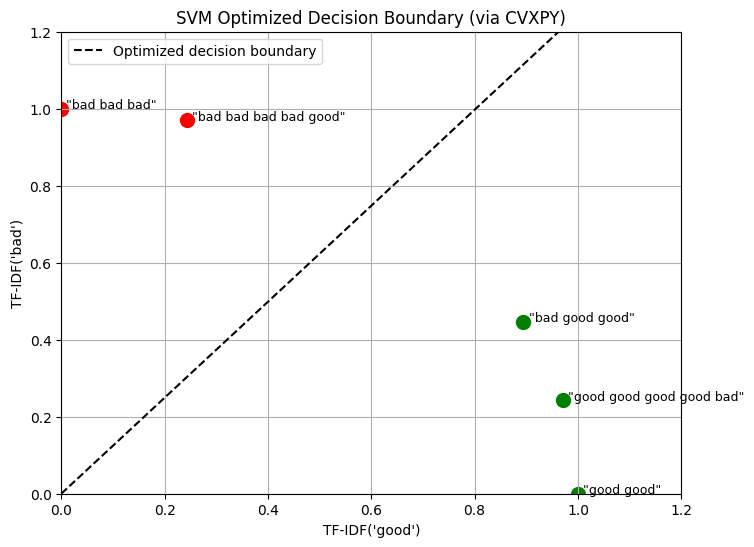

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
import cvxpy as cp

# === Sentences and their labels ===
sentences = [
    "good good good good bad",   # Positive
    "bad bad bad bad good",      # Negative
    "bad bad bad",               # Negative
    "good good",                 # Positive
    "bad good good",             # Positive
]
labels = np.array([1, -1, -1, 1, 1])  # +1 for positive, -1 for negative

# === TF-IDF vectorization with limited vocabulary ===
vectorizer = TfidfVectorizer(vocabulary=["good", "bad"])
X = vectorizer.fit_transform(sentences).toarray()

# === Print TF-IDF vectors ===
print("\nTF-IDF Vectors (columns: 'good', 'bad'):\n")
for i, vector in enumerate(X):
    print(f"Sentence {i+1}: {sentences[i]}")
    print(f"TF-IDF vector: {vector}")
    print("-" * 50)

# === Use CVXPY to optimize w and b ===
w = cp.Variable(2)
b = cp.Variable()

constraints = [labels[i] * (X[i] @ w + b) >= 1 for i in range(len(X))]
objective = cp.Minimize(cp.norm(w, 2))  # Equivalent to maximizing margin
problem = cp.Problem(objective, constraints)
problem.solve()

# Get the optimized values
w_opt = w.value
b_opt = b.value
print(f"\nOptimized w: {w_opt}")
print(f"Optimized b: {b_opt}")

# === Predict using optimized weights ===
scores = X @ w_opt + b_opt
predicted_labels = np.sign(scores)

# === Plotting ===
fig, ax = plt.subplots(figsize=(8, 6))
for i in range(len(X)):
    color = 'green' if labels[i] == 1 else 'red'
    marker = 'o' if predicted_labels[i] == labels[i] else 'x'
    ax.scatter(X[i, 0], X[i, 1], color=color, s=100, marker=marker)
    ax.text(X[i, 0] + 0.01, X[i, 1], f'"{sentences[i]}"', fontsize=9)

# Plot decision boundary: w1*x + w2*y + b = 0  → y = -(w1*x + b)/w2
x_vals = np.linspace(0, 1.2, 100)
if w_opt[1] != 0:
    y_vals = -(w_opt[0] * x_vals + b_opt) / w_opt[1]
    ax.plot(x_vals, y_vals, 'k--', label='Optimized decision boundary')

# Final plot setup
ax.set_xlabel("TF-IDF('good')")
ax.set_ylabel("TF-IDF('bad')")
ax.set_title("SVM Optimized Decision Boundary (via CVXPY)")
ax.set_xlim(0, 1.2)
ax.set_ylim(0, 1.2)
ax.grid(True)
ax.legend()
plt.show()
